In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [51]:
df = pd.read_csv('dataset_creators.csv')

In [52]:
missing_values = ["", " ", "na", "Na", "NA", "null", "Null", "None"]
df = df.replace(missing_values, np.nan)

Text(0.5, 1.0, 'Số lượng giá trị thiếu cho mỗi cột')

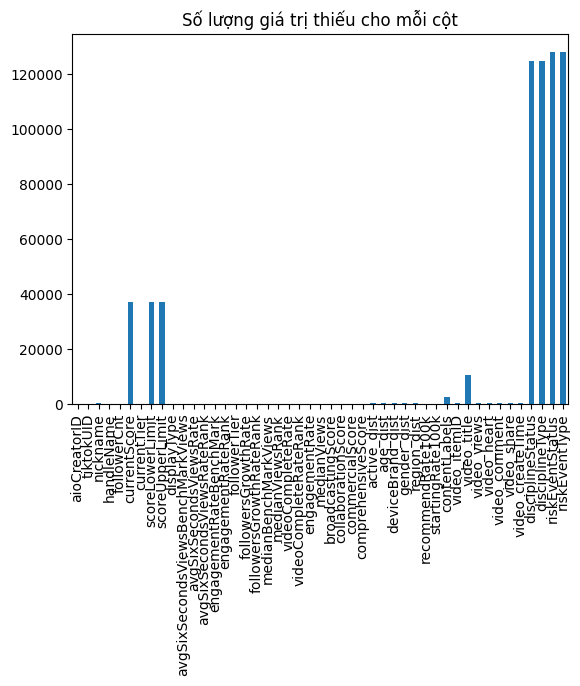

In [53]:
a = df.isna().sum()
a.plot(kind='bar')
plt.title('Số lượng giá trị thiếu cho mỗi cột')

In [54]:
df_nan = df[df['contentLabels'].isna()]

# df_nan.to_csv('creators_nan_nickname.csv', index=False)

In [55]:
len(df_nan)

2464

In [56]:
df_nan = df_nan['handleName']
len(df_nan.unique())

179

In [57]:
# Xóa những tìa khoảng riêng tư không có thông tin
df = df.dropna(subset=['currentTier'])
df = df.dropna(subset=['video_createTime'])

In [58]:
# a = df[df['nickname'] == 'Cậu ~Út']
# a['deviceBrand_dist'].values[0]

In [59]:
df['handleName']

0          ongthibalong
1          ongthibalong
2          ongthibalong
3          ongthibalong
4          ongthibalong
              ...      
144244    plak_official
144245    plak_official
144246         lanhgift
144247         lanhgift
144248         lanhgift
Name: handleName, Length: 144218, dtype: object

In [60]:
# =========================
# =========================

def expand_column(series, key_name):
    def process(x):
        # 1. Null hoặc rỗng
        if pd.isna(x) or x == "" or x == "null":
            return {}

        # 2. Convert string -> python object
        if isinstance(x, str):
            try:
                x = ast.literal_eval(x)
            except:
                return {}

        # 3. Nếu không phải list → bỏ
        if not isinstance(x, list):
            return {}

        result = {}

        for item in x:
            # 4. Kiểm tra dict
            if not isinstance(item, dict):
                continue

            # 5. Lấy key an toàn
            key = item.get(key_name)
            value = item.get('ratio')

            if key is not None and value is not None:
                result[key] = value

        return result

    return series.apply(process).apply(pd.Series)


# =========================
# 3. Expand từng cột
# =========================

# Active
df_active = expand_column(df['active_dist'], 'active')

# Age
df_age = expand_column(df['age_dist'], 'ageInterval')

# Device
df_device = expand_column(df['deviceBrand_dist'], 'deviceBrand')

# Gender
df_gender = expand_column(df['gender_dist'], 'gender')

# Country
df_country = expand_column(df['region_dist'], 'country')


# =========================
# 4. Rename cột để tránh trùng
# =========================
df_active = df_active.add_prefix("active_")
df_age = df_age.add_prefix("age_")
df_device = df_device.add_prefix("device_")
df_gender = df_gender.add_prefix("gender_")
df_country = df_country.add_prefix("country_")


# =========================
# 5. Ghép lại vào DataFrame gốc
# =========================
df_final = pd.concat(
    [df, df_active, df_age, df_device, df_gender, df_country],
    axis=1
)
# =========================
# 7. Kết quả
# =========================
print(df_final.head())


          aioCreatorID            tiktokUID           nickname    handleName  \
0  7418435158459547664  6769061811732956162  Ông Thỉ Bà Long 🌚  ongthibalong   
1  7418435158459547664  6769061811732956162  Ông Thỉ Bà Long 🌚  ongthibalong   
2  7418435158459547664  6769061811732956162  Ông Thỉ Bà Long 🌚  ongthibalong   
3  7418435158459547664  6769061811732956162  Ông Thỉ Bà Long 🌚  ongthibalong   
4  7418435158459547664  6769061811732956162  Ông Thỉ Bà Long 🌚  ongthibalong   

   followerCnt  currentScore  currentTier  scoreLowerLimit  scoreUpperLimit  \
0      1063460          70.0          1.0              0.0            100.0   
1      1063460          70.0          1.0              0.0            100.0   
2      1063460          70.0          1.0              0.0            100.0   
3      1063460          70.0          1.0              0.0            100.0   
4      1063460          70.0          1.0              0.0            100.0   

   displayType  ...  country_JM  country_DO 

In [61]:
df_final.to_csv('creators_expanded.csv', index=False)